In [9]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
print("working")

working


In [10]:
# Define the ODE system
def lotka_volterra(state, t, alpha, beta, delta, gamma):
    x, y = state           # x = rabbits, y = foxes
    dxdt = alpha*x - beta*x*y
    dydt = delta*x*y - gamma*y
    return [dxdt, dydt]

print("ODE defined")

ODE defined


In [11]:
"""
state - Current populations eg -  [x, y] = [rabbits, foxes] at this moment
t - Current time. scipy passes this automatically at each step
alpha - Rabbit birth rate. More rabbits → more babies
beta - Predation rate. How often a rabbit-fox meeting kills a rabbit
delta - Fox growth rate from eating rabbits
gamma - Fox natural death rate
"""

'\nstate - Current populations eg -  [x, y] = [rabbits, foxes] at this moment\nt - Current time. scipy passes this automatically at each step\nalpha - Rabbit birth rate. More rabbits → more babies\nbeta - Predation rate. How often a rabbit-fox meeting kills a rabbit\ndelta - Fox growth rate from eating rabbits\ngamma - Fox natural death rate\n'

In [12]:
# Set parameters and initial conditions
alpha = 1.0
beta  = 0.1
delta = 0.075
gamma = 1.5

x0 = 10   # starting rabbits
y0 = 5    # starting foxes
state0 = [x0, y0]

t = np.linspace(0, 30, 1000)   # time from 0 to 30

print("parameters set")

parameters set


In [13]:
# Solving
solution = odeint(lotka_volterra, state0, t, args=(alpha, beta, delta, gamma))
#solution is a 1000x2 table

rabbits = solution[:, 0]
foxes   = solution[:, 1]

print("Solved. Solution shape:", solution.shape)

Solved. Solution shape: (1000, 2)


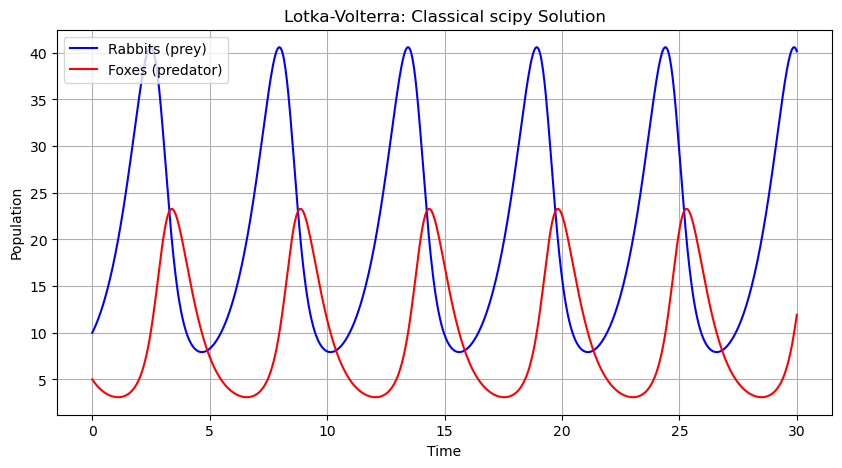

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(t, rabbits, label='Rabbits (prey)', color='blue')
plt.plot(t, foxes,   label='Foxes (predator)', color='red')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Lotka-Volterra: Classical scipy Solution')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
#saving results so we can use in other nb

np.save("ode_t.npy", t)
np.save("ode_rabbits.npy", rabbits)
np.save("ode_foxes.npy", foxes)